In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import sys
from sklearn.metrics import r2_score, mean_squared_error
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import torch
from keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import pickle
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2025-03-16 12:26:10.780234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742153170.792715 2543991 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742153170.796371 2543991 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742153170.806602 2543991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742153170.806614 2543991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742153170.806616 2543991 computation_placer.cc:177] computation placer alr

In [3]:
pkg_path = str(Path(os.getcwd()).parent.absolute())  # Get parent directory of the current working directory
sys.path.insert(0, pkg_path)

# If you need to include a 'src' directory relative to the current notebook:
src_path = os.path.abspath(os.path.join(os.getcwd(), '../src'))  # Adjust path relative to the current working directory
sys.path.insert(0, src_path)
print(f"Path to the 'src' directory: {src_path}")
data_path=pkg_path+'/Datasets/UPENN_GBM/csvs/'
# Now you can import your modules from the 'src' directory
# from src import *

Path to the 'src' directory: /home/ee577/project/src


In [4]:
direct_pairs = '/home/ee577/project/training_data/DSC_ED_merged_data.pkl'

with open(direct_pairs, 'rb') as f:
    _ , y, Z = pickle.load(f) # image, features, survival


In [5]:
Z_log=np.log(Z)
Z_log_norm = (Z_log - np.mean(Z_log)) / np.std(Z_log)
t_half=np.mean(Z_log)
lambda_value=np.log(2)/t_half
Z_norm=np.exp(-Z_log_norm*lambda_value)
Z_norm=(Z_norm-np.mean(Z_norm))
print(lambda_value)

0.11913540154196517


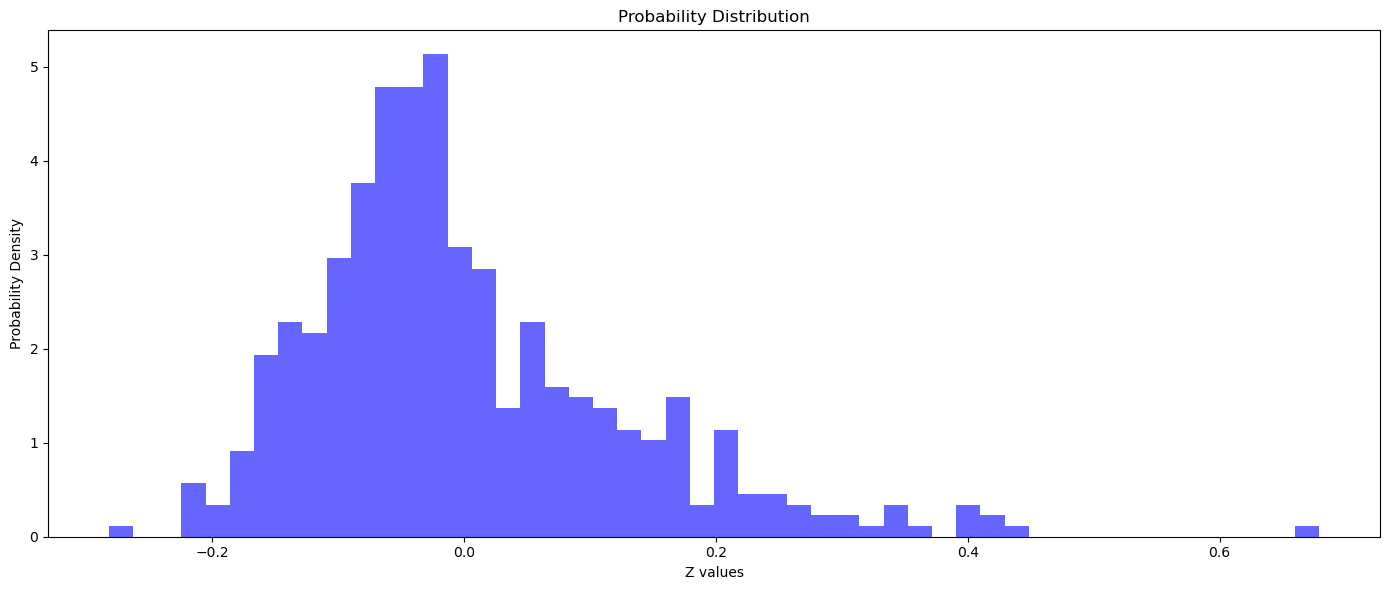

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot Probability Distribution
axes.hist(Z_norm, bins=50, density=True, alpha=0.6, color='blue')
axes.set_title('Probability Distribution')
axes.set_xlabel('Z values')
axes.set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

In [7]:
valid_indices = abs(Z_norm) <= 0.3
Z_norm = Z_norm[valid_indices]
y = y[valid_indices]
scaler = MinMaxScaler()
Z_scaled = scaler.fit_transform(Z_norm.reshape(-1, 1))

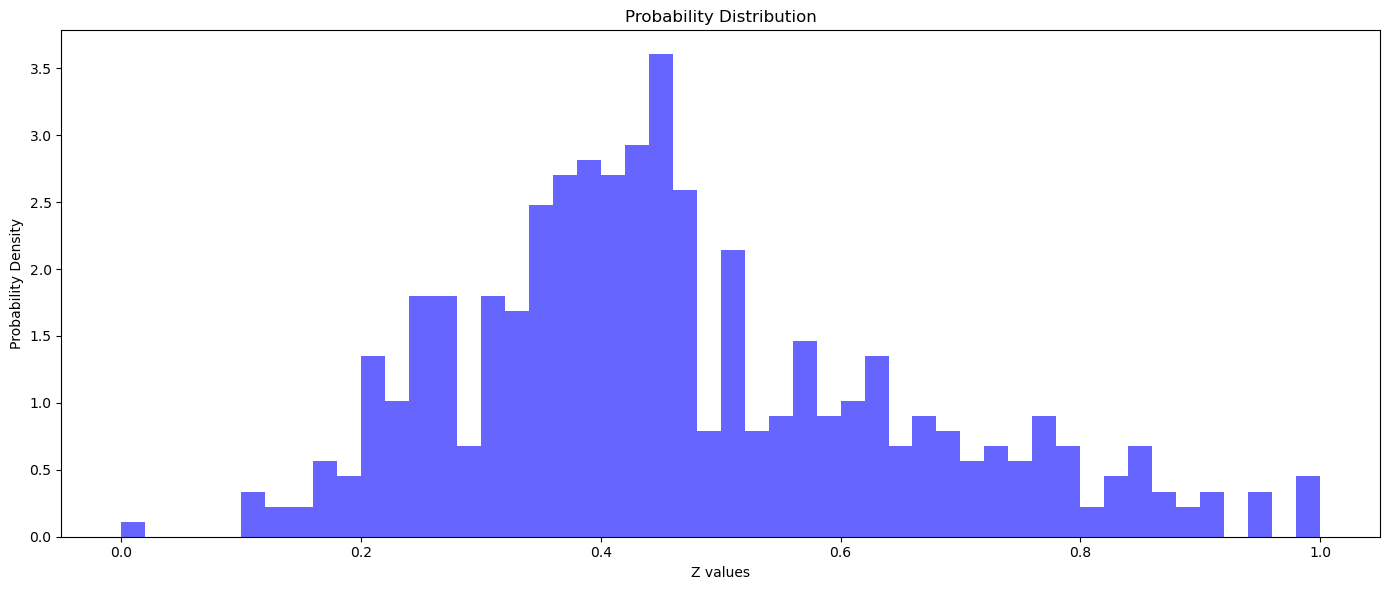

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot Probability Distribution
axes.hist(Z_scaled, bins=50, density=True, alpha=0.6, color='blue')
axes.set_title('Probability Distribution')
axes.set_xlabel('Z values')
axes.set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

In [9]:

print("IDs in y (first 5):", y.shape)
print("IDs in Z (first 5):", Z_norm.shape)

IDs in y (first 5): (444, 55)
IDs in Z (first 5): (444,)


In [10]:
def train_transform(radiomeric_features, survival_days, seed=42):
    """
    Split the dataset into training, validation, and test sets, and scale the features.
    
    Parameters:
    - radiomeric_features: Features used for survival prediction (input data).
    - survival_days: Ground truth survival days (output/target data).
    - seed: Random seed for reproducibility (default 42).
    
    Returns:
    - X_train: Training set features.
    - X_val: Validation set features.
    - X_test: Test set features.
    - y_train: Training set labels (survival days).
    - y_val: Validation set labels.
    - y_test: Test set labels.
    """
    # Split the data into training (80%) and temp (20%) for validation + test
    X_train, X_temp, y_train, y_temp = train_test_split(radiomeric_features, survival_days, test_size=0.2, random_state=seed)
    
    # Split temp into validation (50% of temp) and test (50% of temp) (i.e., 10% of total)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

    # Standardize the features using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [11]:
X_train, X_val, X_test, y_train, y_val, y_test= train_transform(y,Z_norm)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RegressionSurvivalModel(nn.Module):
    def __init__(self, input_size, l1_lambda=1e-9, device='cuda'):
        super(RegressionSurvivalModel, self).__init__()

        self.device = device  # Store device info

        # Define the fully connected layers for regression
        self.first_size = input_size  # Size of input features
        self.fc1 = nn.Linear(self.first_size, 32).to(self.device)   # First fully connected layer
        self.fc2 = nn.Linear(32, 1).to(self.device)                # Second fully connected layer
        # self.fc3 = nn.Linear(32, 1).to(self.device)                 # Third fully connected layer
        # self.fc4 = nn.Linear(32, 1).to(self.device)                  # Final regression layer (single output)

        # Dropout layers
        self.dropout = nn.Dropout(p=0.3).to(self.device)

        # L1 regularization term
        self.l1_lambda = l1_lambda

    def forward(self, x):
        # Forward pass through the fully connected layers
        x = F.relu(self.fc1(x))  # First fully connected layer with ReLU activation
        x = self.dropout(x)      # Apply dropout
        x = F.relu(self.fc2(x))  # Second fully connected layer with ReLU activation
        # x = self.dropout(x)      # Apply dropout
        # x = F.relu(self.fc3(x))  # Third fully connected layer with ReLU activation
        # x = self.dropout(x)      # Apply dropout
        # survival_output = self.fc4(x)  # Final regression output (survival prediction)
        survival_output=x
        return {'survival_output': survival_output}

    def custom_loss(self, survival_output, target_regression):
        """
        Custom loss function for regression. This computes the Smooth L1 loss and 
        adds L1 regularization.
        
        Parameters:
        - survival_output: The predicted output from the model.
        - target_regression: The true target values (survival days).
        
        Returns:
        - total_loss: The total loss (regression loss + L1 regularization).
        """
        # Ensure the target is on the same device as the model output
        target_regression = target_regression.to(self.device)

        # Ensure that survival_output and target_regression have compatible shapes
        if survival_output.ndimension() > 1:
            survival_output = survival_output.squeeze()  # Remove extra dimensions if needed
        
        # Check that the shapes are the same
        assert survival_output.shape == target_regression.shape, \
            f"Shape mismatch: {survival_output.shape} != {target_regression.shape}"

        # Calculate the Smooth L1 loss for regression
        loss_fn = nn.SmoothL1Loss(reduction='mean')
        regression_loss = loss_fn(survival_output, target_regression)

        # Add L1 regularization loss (if applicable)
        l1_loss = self.l1_regularization()

        # Combine the losses
        total_loss = regression_loss + l1_loss
        return total_loss

    def l1_regularization(self):
        # L1 regularization on all model parameters
        l1_norm = sum(p.abs().sum() for p in self.parameters())
        return l1_norm * self.l1_lambda 


In [13]:
def add_noise_to_labels(labels, noise_factor=0.1, seed=None):
    """
    Adds or subtracts noise to labels randomly, based on the seed.
    
    Args:
        labels (Tensor): The tensor of labels to which noise is to be added or subtracted.
        noise_factor (float): The factor by which the noise is scaled (default is 0.1).
        seed (int, optional): A seed for randomness to control noise addition or subtraction. If None, random behavior.
        
    Returns:
        Tensor: Labels with added or subtracted noise.
    """
    # Set the seed if provided to control the randomness
    if seed is not None:
        torch.manual_seed(seed)
    
    noise = torch.randn_like(labels) * noise_factor  # Generate Gaussian noise
    
    # Randomly decide to add or subtract noise
    if torch.randint(0, 2, (1,)).item() == 0:  # Randomly choose 0 or 1
        return labels + noise  # Add noise
    else:
        return labels - noise  # Subtract noise


In [14]:

class CustomDataset(Dataset):
    def __init__(self, features, survival):
    
        self.features= features
        self.survival = survival 

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        features = self.features[idx]
        survival  = self.survival [idx]


        # Convert to torch tensor if necessary
        if isinstance(features, np.ndarray):
            features = torch.tensor(features, dtype=torch.float32).to(device)

        survival = torch.tensor(survival, dtype=torch.float32).to(device)
        return {'features': features, 'survival': survival}

In [15]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import random
import logging
import numpy as np
from torch.nn.utils import clip_grad_norm_

def train_model(
        model, 
        train_loader, 
        val_loader, 
        optimizer, 
        scheduler, 
        num_epochs=50, 
        patience=10, 
        eval_every=2,  
        max_grad_norm=3.0,
        last_epoch=None
        ):
    model.to(device)
    model.train()

    best_val_loss = float('inf')  # Initialize with a large number
    batches_since_improvement = 0  # Count how many epochs since last improvement
    val_losses = []  # List to store the validation losses
    path = f'/home/ee577/project/results/DSC_surv_checkpoint.pth'
    
    # Define epoch range
    if last_epoch:
        epoch_range = range(last_epoch, num_epochs)
    else:
        epoch_range = range(num_epochs)

    for epoch in epoch_range:
        random.seed(epoch)
        np.random.seed(epoch)
        torch.manual_seed(epoch)

        # Iterate over batches in the train_loader
        for batch_idx, batch in enumerate(train_loader):
            # Assuming batch is a dictionary with 'features' and 'survival'
            inputs, labels = batch['features'], batch['survival']

            inputs = inputs.to(device)
            labels = labels.to(device)

            if model.training:  # Add noise only during training
                noisy_labels = add_noise_to_labels(labels, seed=epoch)  

            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            survival_output = outputs['survival_output']

            # Calculate the loss
            train_loss = model.custom_loss(survival_output, labels)  

            # Backpropagation
            train_loss.backward()
            clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            # Average loss for this batch
            train_loss = train_loss.item()

            # Validation loss evaluation
            val_loss = evaluate_validation_loss(model, val_loader)  # model in eval mode
            logging.info(f"Epoch {epoch + 1}/{num_epochs},  Loss: {train_loss:.4f}, Val_loss {val_loss:.4f}, Batch: {batch_idx}")
            print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_loss:.4f}, Val_loss {val_loss:.4f}, Batch: {batch_idx}")
            # Perform validation every `eval_every` epochs
        
            if (batch_idx + 1) % eval_every == 0:
                scheduler.step(val_loss)
                val_losses.append(val_loss)  # Save the validation loss
    
                # Early stopping: Check if validation loss has improved
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    batches_since_improvement = 0
                    # Save model if validation loss improves
                    torch.save(model.state_dict(), f"best_model.pth")
                else:
                    batches_since_improvement += 1

                # Early stopping condition
                if batches_since_improvement >= patience:
                    print(f"Early stopping after {epoch + 1} batches, validation loss has not improved for {patience} epochs.")
                    break
            scheduler.step(val_loss)
        # Clean up memory
        del inputs, labels
        torch.cuda.empty_cache()
    torch.save(model.state_dict(), "last_model.pth")
    return model

def evaluate_validation_loss(model, val_loader):
    """
    Evaluate the model on the validation set and compute the validation loss.
    """
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            # Assuming batch is a dictionary with 'features' and 'survival'
            inputs, labels = batch['features'], batch['survival']

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            survival_output = outputs['survival_output']

            # Calculate loss
            loss = model.custom_loss(survival_output, labels)
            val_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

    avg_val_loss = val_loss / total_samples
    return avg_val_loss



In [16]:
batch_siz=16
train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=batch_siz, shuffle=False)
val_loader = DataLoader(CustomDataset(X_val, y_val), batch_size=batch_siz, shuffle=False)
test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=batch_siz, shuffle=False)

for batch in train_loader:
    survival = batch['survival']
    features = batch['features']
    # print(f"X shape {features.shape}, y shape {survival.shape}")

In [17]:
out_shape=X_train.shape[1:][0]
out_shape

55

In [19]:
from torch.optim import Adam
Input_size=X_train.shape[1:][0]
model = RegressionSurvivalModel( Input_size, device=device)
optimizer = Adam([
 
    {'params': model.fc1.parameters(), 'weight_decay': 0.01},
    {'params': model.fc2.parameters(), 'weight_decay': 0.01},
    # {'params': model.fc3.parameters(), 'weight_decay': 0.01},
    ], lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
    factor=0.1, patience=10, threshold=0.0001, threshold_mode='abs')
trained_model=train_model(model, train_loader, val_loader, optimizer,scheduler, num_epochs=40, patience=10, eval_every=10).to(device)

Epoch 1/40, Loss: 0.0463, Val_loss 0.0253, Batch: 0
Epoch 1/40, Loss: 0.0104, Val_loss 0.0253, Batch: 1
Epoch 1/40, Loss: 0.0162, Val_loss 0.0252, Batch: 2
Epoch 1/40, Loss: 0.0158, Val_loss 0.0252, Batch: 3
Epoch 1/40, Loss: 0.0112, Val_loss 0.0252, Batch: 4
Epoch 1/40, Loss: 0.0062, Val_loss 0.0252, Batch: 5
Epoch 1/40, Loss: 0.0232, Val_loss 0.0251, Batch: 6
Epoch 1/40, Loss: 0.0336, Val_loss 0.0251, Batch: 7
Epoch 1/40, Loss: 0.0137, Val_loss 0.0251, Batch: 8
Epoch 1/40, Loss: 0.0116, Val_loss 0.0250, Batch: 9
Epoch 1/40, Loss: 0.0155, Val_loss 0.0250, Batch: 10
Epoch 1/40, Loss: 0.0318, Val_loss 0.0250, Batch: 11
Epoch 1/40, Loss: 0.0259, Val_loss 0.0249, Batch: 12
Epoch 1/40, Loss: 0.0240, Val_loss 0.0249, Batch: 13
Epoch 1/40, Loss: 0.0383, Val_loss 0.0249, Batch: 14
Epoch 1/40, Loss: 0.0392, Val_loss 0.0248, Batch: 15
Epoch 1/40, Loss: 0.0123, Val_loss 0.0248, Batch: 16
Epoch 1/40, Loss: 0.0333, Val_loss 0.0248, Batch: 17
Epoch 1/40, Loss: 0.0908, Val_loss 0.0247, Batch: 18
Epo

In [20]:
torch.save(trained_model.state_dict(), "DSC_simple_transfer_surv.pth")